# EconML Tutorial 07: Policy Learning And Treatment Targeting

This notebook moves from estimating treatment effects to using them for decisions.

A CATE model answers:

> How much benefit do we expect from treatment for this unit?

A policy answers:

> Which units should we actually treat?

Those are related but not identical. A policy may have a limited budget, a treatment cost, fairness or support constraints, and uncertainty concerns. This notebook teaches how to turn CATE estimates into treatment rules, compare policies, and use EconML's policy learners as another way to learn decision rules directly.

The lesson uses a synthetic truth-known setting so we can evaluate policy value exactly. In real work, policy value usually needs an experiment, randomized holdout, or careful off-policy evaluation.

## Learning Goals

By the end of this notebook, you should be able to:

- distinguish CATE estimation from treatment policy selection;
- define net benefit after treatment cost;
- turn CATE estimates into threshold and budgeted targeting rules;
- compute true policy value in a simulation;
- compare random, treat-all, threshold, top-k, and oracle policies;
- fit EconML `DRPolicyTree` and `DRPolicyForest`;
- compare direct policy learners with CATE-ranking policies;
- inspect treatment rates, segment targeting, regret, and support risks;
- explain why offline policy decisions need uncertainty and overlap checks.

## CATE Versus Policy

A treatment-effect estimate is a score. A policy is an action rule.

For binary treatment, a simple policy can be written as:

`policy(X) = 1 if estimated_net_CATE(X) > threshold else 0`

where:

`estimated_net_CATE = estimated_outcome_CATE - treatment_cost`

If there is no budget constraint, a simple rule treats units with positive estimated net benefit. If there is a budget constraint, the rule may treat only the top `k%` of units ranked by estimated net benefit.

The key evaluation quantity in this notebook is policy gain relative to treating nobody:

`policy_gain = mean(policy(X) * true_net_CATE(X))`

A good policy has high positive gain, treats a defensible share of the population, and avoids overreliance on noisy or unsupported regions.

## Tutorial Flow

The notebook follows this path:

1. Create a confounded dataset with true potential outcomes and treatment cost.
2. Define true net CATE and oracle policy value.
3. Fit CATE models that estimate net treatment benefit.
4. Convert CATE scores into threshold and budgeted policies.
5. Fit direct EconML policy learners.
6. Compare policy gain, regret, treatment rate, and segment targeting.
7. Inspect policy trees and feature importances.
8. Evaluate support and uncertainty risks.
9. Close with a practical policy-learning checklist.

## Setup

This cell imports packages, creates output folders, fixes a random seed, and checks whether the EconML estimators needed for the notebook are available.

In [1]:
from pathlib import Path
import os
import warnings
import importlib.metadata as importlib_metadata

# Keep Matplotlib cache files in a writable location during notebook execution.
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-ranking-sys")

warnings.filterwarnings("default")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*IProgress not found.*")
warnings.filterwarnings("ignore", message=".*X does not have valid feature names.*")
warnings.filterwarnings("ignore", message=".*The final model has a nonzero intercept.*")
warnings.filterwarnings("ignore", message=".*Co-variance matrix is underdetermined.*")
warnings.filterwarnings("ignore", module="sklearn.linear_model._logistic")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree

from IPython.display import display
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import brier_score_loss, log_loss, mean_squared_error, roc_auc_score
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_predict, train_test_split

try:
    import econml
    from econml.dml import CausalForestDML, LinearDML
    from econml.dr import DRLearner
    from econml.policy import DRPolicyTree, DRPolicyForest
    ECONML_AVAILABLE = True
    ECONML_VERSION = getattr(econml, "__version__", "unknown")
except Exception as exc:
    ECONML_AVAILABLE = False
    ECONML_VERSION = f"import failed: {type(exc).__name__}: {exc}"

RANDOM_SEED = 2026
rng = np.random.default_rng(RANDOM_SEED)

OUTPUT_DIR = Path("outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 140)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print(f"EconML available: {ECONML_AVAILABLE}")
print(f"EconML version: {ECONML_VERSION}")
print(f"Figures will be saved to: {FIGURE_DIR.resolve()}")
print(f"Tables will be saved to: {TABLE_DIR.resolve()}")

EconML available: True
EconML version: 0.16.0
Figures will be saved to: /home/apex/Documents/ranking_sys/notebooks/tutorials/econml/outputs/figures
Tables will be saved to: /home/apex/Documents/ranking_sys/notebooks/tutorials/econml/outputs/tables


What this shows: the notebook is ready if EconML imports successfully. The output files use the `07_` prefix so they are easy to separate from earlier tutorial artifacts.

## Policy Objects In This Lesson

The next table names the policy strategies we will compare. Some are simple score-based rules; others are learned directly by EconML policy estimators.

In [2]:
policy_strategy_map = pd.DataFrame(
    [
        {
            "policy family": "Treat nobody",
            "how it works": "Set treatment to 0 for every unit",
            "why include it": "Baseline value for policy gain",
        },
        {
            "policy family": "Treat everybody",
            "how it works": "Set treatment to 1 for every unit",
            "why include it": "Shows whether treatment is beneficial on average after cost",
        },
        {
            "policy family": "CATE threshold",
            "how it works": "Treat when estimated net CATE is above zero",
            "why include it": "Natural rule without a fixed budget",
        },
        {
            "policy family": "Budgeted top-k",
            "how it works": "Treat the top share of units ranked by estimated net CATE",
            "why include it": "Matches constrained treatment capacity",
        },
        {
            "policy family": "DRPolicyTree / DRPolicyForest",
            "how it works": "Learn a decision rule directly from observed outcomes, treatment, X, and W",
            "why include it": "Uses EconML's direct policy-learning tools",
        },
        {
            "policy family": "Oracle",
            "how it works": "Treat using true net CATE",
            "why include it": "Upper benchmark available only in simulation",
        },
    ]
)

policy_strategy_map.to_csv(TABLE_DIR / "07_policy_strategy_map.csv", index=False)
display(policy_strategy_map)

,policy family,how it works,why include it
0,Treat nobody,Set treatment to 0 for every unit,Baseline value for policy gain
1,Treat everybody,Set treatment to 1 for every unit,Shows whether treatment is beneficial on avera...
2,CATE threshold,Treat when estimated net CATE is above zero,Natural rule without a fixed budget
3,Budgeted top-k,Treat the top share of units ranked by estimat...,Matches constrained treatment capacity
4,DRPolicyTree / DRPolicyForest,Learn a decision rule directly from observed o...,Uses EconML's direct policy-learning tools
5,Oracle,Treat using true net CATE,Upper benchmark available only in simulation


What this shows: a policy comparison should include simple baselines. A complicated learner is only useful if it improves over clear rules like treat nobody, treat everybody, and top-k targeting.

## Synthetic Teaching Data

The dataset below has a binary treatment, observed confounding, heterogeneous treatment effects, and an explicit treatment cost.

The observed outcome is a gross benefit. We create a net outcome by subtracting treatment cost from treated rows:

`observed_net_outcome = observed_outcome - treatment_cost * treatment`

The policy problem is to maximize expected net outcome, not just gross outcome. That distinction matters because some units may have positive gross treatment effects but negative net effects after cost.

In [3]:
n = 3_000
TREATMENT_COST = 0.28

baseline_need = rng.normal(0, 1, size=n)
prior_engagement = rng.normal(0, 1, size=n)
friction_score = 0.50 * baseline_need - 0.25 * prior_engagement + rng.normal(0, 0.85, size=n)
content_affinity = 0.38 * prior_engagement + rng.normal(0, 0.95, size=n)
price_sensitivity = rng.normal(0, 1, size=n)
trust_score = rng.normal(0, 1, size=n)
recency_gap = rng.normal(0, 1, size=n)
region_risk = rng.binomial(1, 0.35, size=n)
high_need_segment = (baseline_need > 0.55).astype(int)

account_tenure = rng.normal(0, 1, size=n)
seasonality_index = rng.normal(0, 1, size=n)
device_stability = rng.normal(0, 1, size=n)
traffic_intensity = rng.normal(0, 1, size=n)

propensity_logit = (
    -0.35
    + 0.78 * baseline_need
    + 0.44 * prior_engagement
    + 0.40 * friction_score
    + 0.32 * content_affinity
    - 0.20 * trust_score
    + 0.26 * region_risk
    + 0.24 * high_need_segment
    - 0.28 * account_tenure
    + 0.22 * seasonality_index
    + 0.15 * traffic_intensity
)
propensity = 1 / (1 + np.exp(-propensity_logit))
propensity = np.clip(propensity, 0.035, 0.965)
treatment = rng.binomial(1, propensity, size=n)

gross_cate = (
    0.42
    + 0.34 * high_need_segment
    + 0.24 * np.tanh(prior_engagement)
    - 0.24 * np.maximum(friction_score, 0)
    + 0.18 * content_affinity
    - 0.16 * region_risk
    - 0.14 * (price_sensitivity > 0.75).astype(float)
    + 0.10 * np.sin(content_affinity + baseline_need)
)
true_net_cate = gross_cate - TREATMENT_COST

mu0 = (
    2.10
    + 0.78 * baseline_need
    + 0.58 * prior_engagement
    - 0.48 * friction_score
    + 0.28 * content_affinity
    + 0.22 * trust_score
    + 0.34 * account_tenure
    + 0.22 * seasonality_index
    + 0.18 * device_stability
    + 0.16 * traffic_intensity
    + 0.16 * region_risk
    + 0.12 * baseline_need * friction_score
)
mu1 = mu0 + gross_cate
noise = rng.normal(0, 0.90, size=n)
outcome = np.where(treatment == 1, mu1, mu0) + noise
net_outcome = outcome - TREATMENT_COST * treatment

teaching_df = pd.DataFrame(
    {
        "user_id": np.arange(n),
        "baseline_need": baseline_need,
        "prior_engagement": prior_engagement,
        "friction_score": friction_score,
        "content_affinity": content_affinity,
        "price_sensitivity": price_sensitivity,
        "trust_score": trust_score,
        "recency_gap": recency_gap,
        "region_risk": region_risk,
        "high_need_segment": high_need_segment,
        "account_tenure": account_tenure,
        "seasonality_index": seasonality_index,
        "device_stability": device_stability,
        "traffic_intensity": traffic_intensity,
        "propensity": propensity,
        "treatment": treatment,
        "outcome": outcome,
        "net_outcome": net_outcome,
        "mu0": mu0,
        "mu1": mu1,
        "gross_cate": gross_cate,
        "true_net_cate": true_net_cate,
    }
)

teaching_df.head()

,user_id,baseline_need,prior_engagement,friction_score,content_affinity,price_sensitivity,trust_score,recency_gap,region_risk,high_need_segment,account_tenure,seasonality_index,device_stability,traffic_intensity,propensity,treatment,outcome,net_outcome,mu0,mu1,gross_cate,true_net_cate
0,0,-0.7931,-0.4520,0.0233,1.2695,1.4847,0.5943,1.6834,0,0,-0.3757,-1.0499,-0.0713,1.7041,0.3228,0,1.6283,1.6283,1.5931,2.0403,0.4471,0.1671
1,1,0.2406,-0.3531,-0.7239,-0.7717,-1.7368,1.3611,-1.4981,1,0,0.0106,-1.5990,-0.4807,2.2731,0.2931,0,3.6170,3.6170,2.5818,2.5708,-0.0109,-0.2909
2,2,-1.8963,-0.9423,-1.1321,0.5177,0.9344,1.2671,2.8652,1,0,1.6226,0.3719,-1.0464,-1.3406,0.0432,0,2.3763,2.3763,1.6897,1.6280,-0.0617,-0.3417
3,3,1.3958,0.0110,1.1108,0.1338,0.2148,0.6624,-0.2507,1,1,-1.5408,-1.8431,0.3545,0.7243,0.8498,1,5.4312,5.1512,2.4415,2.9016,0.4601,0.1801
4,4,0.6383,1.1904,-0.4781,1.9206,-0.3884,0.0489,-1.8590,1,1,-0.5915,-0.6628,0.1159,-0.8280,0.8147,1,3.6548,3.3748,3.7312,4.9313,1.2001,0.9201


What this shows: policy learning is being framed as net value maximization. The gross CATE can be positive while the net CATE is negative if the treatment cost is larger than expected benefit.

## Field Dictionary

This table clarifies which fields are observed in a real analysis and which are oracle fields available only because we simulated the data.

In [4]:
effect_modifier_cols = [
    "baseline_need",
    "prior_engagement",
    "friction_score",
    "content_affinity",
    "price_sensitivity",
    "region_risk",
    "high_need_segment",
]
control_cols = ["trust_score", "recency_gap", "account_tenure", "seasonality_index", "device_stability", "traffic_intensity"]
all_observed_covariates = effect_modifier_cols + control_cols
true_driver_cols = effect_modifier_cols.copy()

field_rows = []
for col in effect_modifier_cols:
    field_rows.append(
        {
            "column": col,
            "role": "X policy/CATE feature",
            "observed_in_real_analysis": "yes",
            "description": "Pre-treatment feature used for treatment-effect ranking and policy decisions.",
            "true_net_cate_driver": "yes" if col in true_driver_cols else "no",
        }
    )
for col in control_cols:
    field_rows.append(
        {
            "column": col,
            "role": "W/control or support feature",
            "observed_in_real_analysis": "yes",
            "description": "Pre-treatment feature used for nuisance adjustment and support diagnostics.",
            "true_net_cate_driver": "no",
        }
    )
for col, role, description in [
    ("treatment", "treatment", "Binary intervention indicator."),
    ("outcome", "observed outcome", "Observed gross post-treatment outcome."),
    ("net_outcome", "observed net outcome", "Observed outcome after subtracting treatment cost for treated rows."),
    ("propensity", "oracle", "True treatment probability from the simulated assignment process."),
    ("mu0", "oracle", "True conditional mean outcome under control."),
    ("mu1", "oracle", "True conditional mean gross outcome under treatment."),
    ("gross_cate", "oracle", "Known gross individual treatment effect."),
    ("true_net_cate", "oracle", "Known treatment effect after subtracting treatment cost."),
]:
    field_rows.append(
        {
            "column": col,
            "role": role,
            "observed_in_real_analysis": "yes" if role in ["treatment", "observed outcome", "observed net outcome"] else "no",
            "description": description,
            "true_net_cate_driver": "not applicable",
        }
    )

field_dictionary = pd.DataFrame(field_rows)
field_dictionary.to_csv(TABLE_DIR / "07_field_dictionary.csv", index=False)
display(field_dictionary)

,column,role,observed_in_real_analysis,description,true_net_cate_driver
0,baseline_need,X policy/CATE feature,yes,Pre-treatment feature used for treatment-effec...,yes
1,prior_engagement,X policy/CATE feature,yes,Pre-treatment feature used for treatment-effec...,yes
2,friction_score,X policy/CATE feature,yes,Pre-treatment feature used for treatment-effec...,yes
3,content_affinity,X policy/CATE feature,yes,Pre-treatment feature used for treatment-effec...,yes
4,price_sensitivity,X policy/CATE feature,yes,Pre-treatment feature used for treatment-effec...,yes
5,region_risk,X policy/CATE feature,yes,Pre-treatment feature used for treatment-effec...,yes
6,high_need_segment,X policy/CATE feature,yes,Pre-treatment feature used for treatment-effec...,yes
7,trust_score,W/control or support feature,yes,Pre-treatment feature used for nuisance adjust...,no
8,recency_gap,W/control or support feature,yes,Pre-treatment feature used for nuisance adjust...,no
9,account_tenure,W/control or support feature,yes,Pre-treatment feature used for nuisance adjust...,no


What this shows: the fitted models should use only observed pre-treatment features, treatment, and net outcome. Oracle fields are reserved for policy evaluation in the tutorial.

## Basic Shape And Net Effect Scale

Before fitting any model, we summarize treatment rate, gross treatment effects, and net treatment effects.

In [5]:
basic_summary = pd.DataFrame(
    [
        {"metric": "rows", "value": len(teaching_df)},
        {"metric": "columns", "value": teaching_df.shape[1]},
        {"metric": "treatment_cost", "value": TREATMENT_COST},
        {"metric": "treatment_rate", "value": teaching_df["treatment"].mean()},
        {"metric": "gross_ate", "value": teaching_df["gross_cate"].mean()},
        {"metric": "true_net_ate", "value": teaching_df["true_net_cate"].mean()},
        {"metric": "share_positive_gross_cate", "value": (teaching_df["gross_cate"] > 0).mean()},
        {"metric": "share_positive_net_cate", "value": (teaching_df["true_net_cate"] > 0).mean()},
        {"metric": "true_net_cate_std", "value": teaching_df["true_net_cate"].std()},
        {"metric": "true_net_cate_min", "value": teaching_df["true_net_cate"].min()},
        {"metric": "true_net_cate_max", "value": teaching_df["true_net_cate"].max()},
    ]
)

basic_summary.to_csv(TABLE_DIR / "07_basic_summary.csv", index=False)
display(basic_summary)

,metric,value
0,rows,"3,000.0000"
1,columns,22.0000
2,treatment_cost,0.2800
3,treatment_rate,0.4567
4,gross_ate,0.3413
5,true_net_ate,0.0613
6,share_positive_gross_cate,0.8033
7,share_positive_net_cate,0.5500
8,true_net_cate_std,0.3923
9,true_net_cate_min,-1.2210


What this shows: treatment is not automatically worth applying to everyone. The share of positive net CATE defines the approximate size of the unconstrained oracle policy.

## Net CATE Distribution

This plot shows who has positive or negative true net benefit. The vertical zero line is the natural threshold for an unconstrained policy.

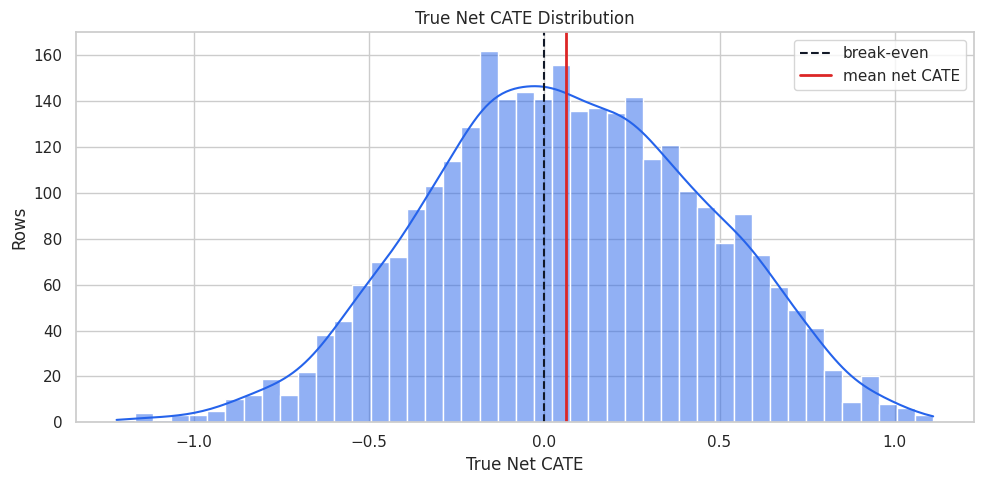

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(teaching_df["true_net_cate"], bins=45, kde=True, color="#2563eb", ax=ax)
ax.axvline(0, color="#111827", linewidth=1.5, linestyle="--", label="break-even")
ax.axvline(teaching_df["true_net_cate"].mean(), color="#dc2626", linewidth=2, label="mean net CATE")
ax.set_title("True Net CATE Distribution")
ax.set_xlabel("True Net CATE")
ax.set_ylabel("Rows")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / "07_true_net_cate_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

What this shows: some units are below the break-even line. Good targeting should avoid treating them when possible, especially under a limited budget.

## Raw Treated-Versus-Control Net Difference

A raw net-outcome difference is not a policy estimate. It mixes treatment effect, treatment cost, and selection into treatment.

In [7]:
raw_group_summary = (
    teaching_df.groupby("treatment")
    .agg(
        rows=("net_outcome", "size"),
        observed_net_outcome_mean=("net_outcome", "mean"),
        true_net_cate_mean=("true_net_cate", "mean"),
        propensity_mean=("propensity", "mean"),
        baseline_need_mean=("baseline_need", "mean"),
        friction_score_mean=("friction_score", "mean"),
        content_affinity_mean=("content_affinity", "mean"),
    )
    .reset_index()
)
raw_net_difference = (
    raw_group_summary.loc[raw_group_summary["treatment"].eq(1), "observed_net_outcome_mean"].iloc[0]
    - raw_group_summary.loc[raw_group_summary["treatment"].eq(0), "observed_net_outcome_mean"].iloc[0]
)
true_net_ate = teaching_df["true_net_cate"].mean()
raw_difference_summary = pd.DataFrame(
    [
        {"quantity": "raw treated minus untreated net outcome mean", "value": raw_net_difference},
        {"quantity": "true net ATE", "value": true_net_ate},
        {"quantity": "raw difference minus true net ATE", "value": raw_net_difference - true_net_ate},
    ]
)

raw_group_summary.to_csv(TABLE_DIR / "07_raw_group_summary.csv", index=False)
raw_difference_summary.to_csv(TABLE_DIR / "07_raw_difference_vs_truth.csv", index=False)
display(raw_group_summary)
display(raw_difference_summary)

,treatment,rows,observed_net_outcome_mean,true_net_cate_mean,propensity_mean,baseline_need_mean,friction_score_mean,content_affinity_mean
0,0,1630,1.9006,-0.0308,0.3364,-0.4163,-0.2669,-0.1459
1,1,1370,2.7439,0.1710,0.6010,0.4301,0.2637,0.1808


,quantity,value
0,raw treated minus untreated net outcome mean,0.8433
1,true net ATE,0.0613
2,raw difference minus true net ATE,0.7820


What this shows: treated and untreated rows differ in baseline features and true net benefit. Policy learning needs adjustment, not raw group comparisons.

## Covariate Balance Check

Standardized mean differences show how different treated and untreated groups are before modeling.

In [8]:
balance_rows = []
for col in all_observed_covariates:
    treated_values = teaching_df.loc[teaching_df["treatment"].eq(1), col]
    control_values = teaching_df.loc[teaching_df["treatment"].eq(0), col]
    pooled_sd = np.sqrt((treated_values.var(ddof=1) + control_values.var(ddof=1)) / 2)
    balance_rows.append(
        {
            "covariate": col,
            "treated_mean": treated_values.mean(),
            "control_mean": control_values.mean(),
            "standardized_difference": (treated_values.mean() - control_values.mean()) / pooled_sd,
        }
    )

balance_table = pd.DataFrame(balance_rows).sort_values("standardized_difference", key=lambda s: s.abs(), ascending=False)
balance_table.to_csv(TABLE_DIR / "07_covariate_balance.csv", index=False)
display(balance_table)

,covariate,treated_mean,control_mean,standardized_difference
0,baseline_need,0.4301,-0.4163,0.9205
6,high_need_segment,0.4650,0.1399,0.7565
2,friction_score,0.2637,-0.2669,0.5384
1,prior_engagement,0.2295,-0.1412,0.3768
3,content_affinity,0.1808,-0.1459,0.3221
12,traffic_intensity,0.1186,-0.0799,0.2011
9,account_tenure,-0.0954,0.0990,-0.1909
7,trust_score,-0.0846,0.0977,-0.1830
5,region_risk,0.3591,0.3196,0.0834
10,seasonality_index,0.0082,-0.0576,0.0674


What this shows: treatment is observably confounded. The same support and adjustment concerns from CATE estimation carry into policy learning.

## Covariate Balance Plot

The plot highlights the most imbalanced pre-treatment features.

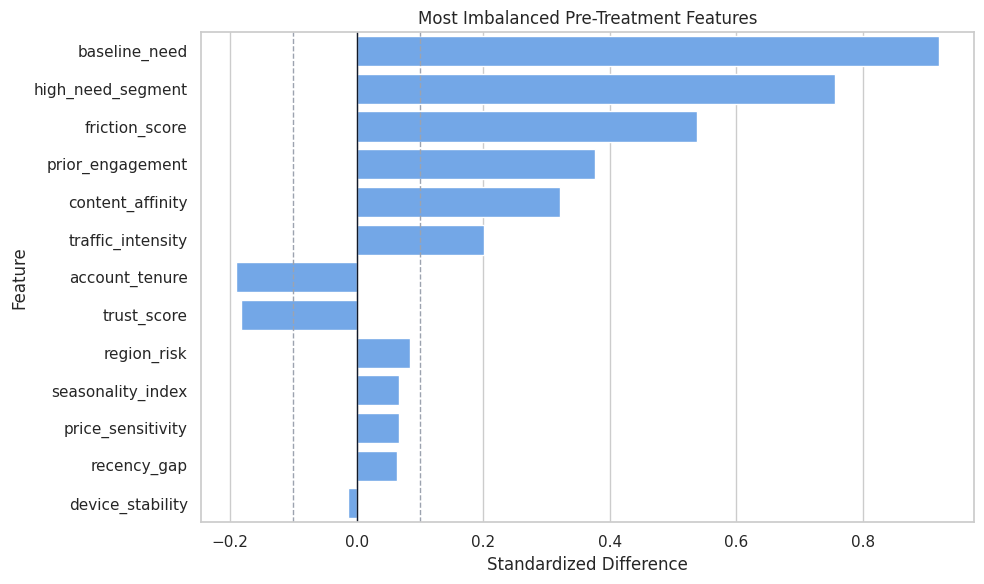

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=balance_table.head(13),
    x="standardized_difference",
    y="covariate",
    color="#60a5fa",
    ax=ax,
)
ax.axvline(0, color="#111827", linewidth=1)
ax.axvline(0.10, color="#9ca3af", linewidth=1, linestyle="--")
ax.axvline(-0.10, color="#9ca3af", linewidth=1, linestyle="--")
ax.set_title("Most Imbalanced Pre-Treatment Features")
ax.set_xlabel("Standardized Difference")
ax.set_ylabel("Feature")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "07_covariate_balance.png", dpi=160, bbox_inches="tight")
plt.show()

What this shows: the policy problem is observational, so learned policies should be treated as candidates for evaluation rather than automatically deployable rules.

## Propensity Overlap

Policy learning can fail in regions where one action is rarely observed. The next table summarizes treatment rates and net effects by true propensity bucket.

In [10]:
propensity_summary = (
    teaching_df.assign(propensity_bucket=pd.cut(teaching_df["propensity"], bins=np.linspace(0, 1, 11), include_lowest=True))
    .groupby("propensity_bucket", observed=True)
    .agg(
        rows=("propensity", "size"),
        treatment_rate=("treatment", "mean"),
        true_net_cate_mean=("true_net_cate", "mean"),
        baseline_need_mean=("baseline_need", "mean"),
    )
    .reset_index()
)
propensity_summary["propensity_bucket"] = propensity_summary["propensity_bucket"].astype(str)
propensity_summary.to_csv(TABLE_DIR / "07_propensity_bucket_summary.csv", index=False)
display(propensity_summary)

,propensity_bucket,rows,treatment_rate,true_net_cate_mean,baseline_need_mean
0,"(-0.001, 0.1]",196,0.0765,-0.2308,-1.4609
1,"(0.1, 0.2]",394,0.1396,-0.1902,-0.9668
2,"(0.2, 0.3]",374,0.2273,-0.0913,-0.5870
3,"(0.3, 0.4]",387,0.3488,-0.0149,-0.3482
4,"(0.4, 0.5]",391,0.4399,0.0504,-0.0150
5,"(0.5, 0.6]",316,0.5538,0.1426,0.2446
6,"(0.6, 0.7]",276,0.6486,0.2338,0.4927
7,"(0.7, 0.8]",308,0.7792,0.2953,0.8007
8,"(0.8, 0.9]",262,0.8588,0.3195,1.1600
9,"(0.9, 1.0]",96,0.9271,0.4184,1.8146


What this shows: policy value is easiest to trust in propensity regions where both actions have support. Extreme buckets require more caution.

## Propensity Overlap Plot

The histogram shows the true propensity distribution by observed treatment group. In real data, this would use an estimated propensity model.

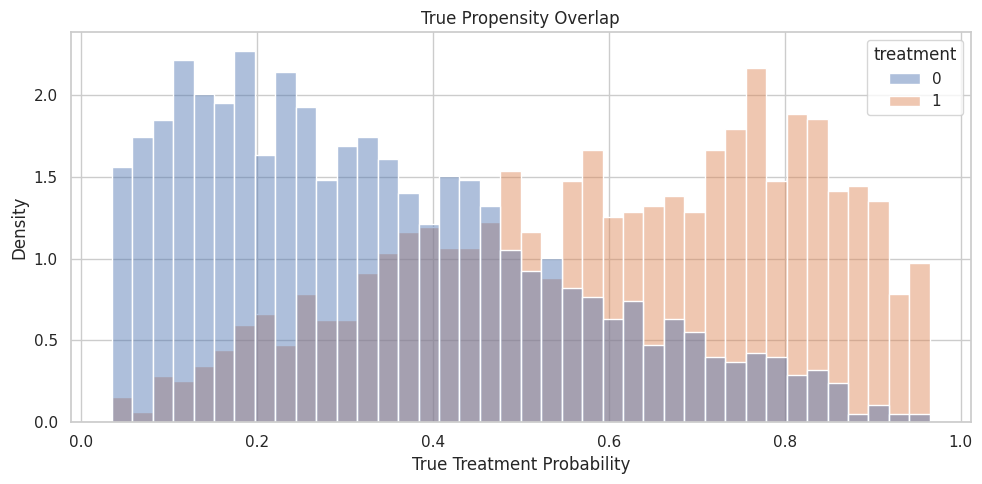

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    data=teaching_df,
    x="propensity",
    hue="treatment",
    bins=40,
    stat="density",
    common_norm=False,
    alpha=0.45,
    ax=ax,
)
ax.set_title("True Propensity Overlap")
ax.set_xlabel("True Treatment Probability")
ax.set_ylabel("Density")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "07_propensity_overlap.png", dpi=160, bbox_inches="tight")
plt.show()

What this shows: the groups overlap but are shifted. This is a reasonable teaching case for policy learning, but not a randomized experiment.

## Train And Test Split

The train set fits CATE and policy learners. The test set evaluates policy value using known true net CATE.

In [12]:
train_idx, test_idx = train_test_split(
    teaching_df.index,
    test_size=0.35,
    random_state=RANDOM_SEED,
    stratify=teaching_df["treatment"],
)
train_df = teaching_df.loc[train_idx].reset_index(drop=True)
test_df = teaching_df.loc[test_idx].reset_index(drop=True)

split_summary = pd.DataFrame(
    [
        {"split": "train", "rows": len(train_df), "treatment_rate": train_df["treatment"].mean(), "true_net_ate": train_df["true_net_cate"].mean()},
        {"split": "test", "rows": len(test_df), "treatment_rate": test_df["treatment"].mean(), "true_net_ate": test_df["true_net_cate"].mean()},
    ]
)

split_summary.to_csv(TABLE_DIR / "07_train_test_split_summary.csv", index=False)
display(split_summary)

,split,rows,treatment_rate,true_net_ate
0,train,1950,0.4564,0.0586
1,test,1050,0.4571,0.0665


What this shows: the test set is similar to the train set in treatment rate and true net ATE. That makes policy comparisons easier to read.

## Modeling Matrices

This cell creates the arrays passed to EconML estimators. We estimate effects on net outcome, because policy value should account for treatment cost.

In [13]:
Y_net_train = train_df["net_outcome"].to_numpy()
T_train = train_df["treatment"].to_numpy()
Y_net_test = test_df["net_outcome"].to_numpy()
T_test = test_df["treatment"].to_numpy()

X_train = train_df[effect_modifier_cols]
X_test = test_df[effect_modifier_cols]
W_train = train_df[control_cols]
W_test = test_df[control_cols]
all_features_train = train_df[all_observed_covariates]
all_features_test = test_df[all_observed_covariates]
true_net_cate_test = test_df["true_net_cate"].to_numpy()

matrix_summary = pd.DataFrame(
    [
        {"object": "Y_net_train", "rows": Y_net_train.shape[0], "columns": 1, "meaning": "Observed net outcome used for policy-value learning."},
        {"object": "T_train", "rows": T_train.shape[0], "columns": 1, "meaning": "Observed binary treatment."},
        {"object": "X_train", "rows": X_train.shape[0], "columns": X_train.shape[1], "meaning": "Effect modifiers and policy features."},
        {"object": "W_train", "rows": W_train.shape[0], "columns": W_train.shape[1], "meaning": "Additional controls for nuisance adjustment."},
        {"object": "true_net_cate_test", "rows": true_net_cate_test.shape[0], "columns": 1, "meaning": "Oracle net effect used only for policy evaluation."},
    ]
)

matrix_summary.to_csv(TABLE_DIR / "07_model_matrix_summary.csv", index=False)
display(matrix_summary)

,object,rows,columns,meaning
0,Y_net_train,1950,1,Observed net outcome used for policy-value lea...
1,T_train,1950,1,Observed binary treatment.
2,X_train,1950,7,Effect modifiers and policy features.
3,W_train,1950,6,Additional controls for nuisance adjustment.
4,true_net_cate_test,1050,1,Oracle net effect used only for policy evaluat...


What this shows: once treatment cost is folded into the outcome, the CATE from these estimators is a net benefit estimate. That makes policy thresholding straightforward.

## Nuisance Diagnostics

Before fitting policy models, we check whether treatment and net outcome are predictable from observed pre-treatment features.

In [14]:
outcome_probe = RandomForestRegressor(n_estimators=140, min_samples_leaf=20, random_state=RANDOM_SEED, n_jobs=-1)
treatment_probe = RandomForestClassifier(n_estimators=140, min_samples_leaf=20, random_state=RANDOM_SEED, n_jobs=-1)

outcome_cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
treatment_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
net_y_oof = cross_val_predict(outcome_probe, all_features_train, Y_net_train, cv=outcome_cv, method="predict")
t_oof = cross_val_predict(treatment_probe, all_features_train, T_train, cv=treatment_cv, method="predict_proba")[:, 1]

nuisance_diagnostics = pd.DataFrame(
    [
        {"nuisance_model": "net outcome E[Y_net | X, W]", "metric": "out_of_fold_rmse", "value": np.sqrt(mean_squared_error(Y_net_train, net_y_oof))},
        {"nuisance_model": "treatment E[T | X, W]", "metric": "out_of_fold_auc", "value": roc_auc_score(T_train, t_oof)},
        {"nuisance_model": "treatment E[T | X, W]", "metric": "out_of_fold_brier_score", "value": brier_score_loss(T_train, t_oof)},
        {"nuisance_model": "treatment E[T | X, W]", "metric": "out_of_fold_log_loss", "value": log_loss(T_train, t_oof)},
    ]
)

nuisance_diagnostics.to_csv(TABLE_DIR / "07_nuisance_diagnostics.csv", index=False)
display(nuisance_diagnostics)

,nuisance_model,metric,value
0,"net outcome E[Y_net | X, W]",out_of_fold_rmse,1.1208
1,"treatment E[T | X, W]",out_of_fold_auc,0.7763
2,"treatment E[T | X, W]",out_of_fold_brier_score,0.1927
3,"treatment E[T | X, W]",out_of_fold_log_loss,0.5690


What this shows: assignment is predictable, so this is an observational policy problem. The policy learners need nuisance adjustment rather than simple outcome comparisons.

## Fit Net CATE Models

We fit three CATE models on net outcome:

- `LinearDML` as a readable baseline;
- `CausalForestDML` as a flexible CATE model with intervals;
- `DRLearner` with a forest final model as a doubly robust pseudo-outcome approach.

Each model estimates net benefit from treatment, because the outcome already subtracts treatment cost.

In [15]:
if not ECONML_AVAILABLE:
    raise ImportError(f"EconML is not available in this environment: {ECONML_VERSION}")

linear_dml = LinearDML(
    model_y=RandomForestRegressor(n_estimators=120, min_samples_leaf=20, random_state=RANDOM_SEED + 1, n_jobs=-1),
    model_t=RandomForestClassifier(n_estimators=120, min_samples_leaf=20, random_state=RANDOM_SEED + 1, n_jobs=-1),
    discrete_treatment=True,
    fit_cate_intercept=True,
    cv=5,
    random_state=RANDOM_SEED,
)
linear_dml.fit(Y_net_train, T_train, X=X_train, W=W_train, inference=None)
linear_net_cate_test = np.ravel(linear_dml.effect(X_test))

causal_forest = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=130, min_samples_leaf=20, random_state=RANDOM_SEED + 2, n_jobs=-1),
    model_t=RandomForestClassifier(n_estimators=130, min_samples_leaf=20, random_state=RANDOM_SEED + 2, n_jobs=-1),
    discrete_treatment=True,
    cv=5,
    n_estimators=180,
    min_samples_leaf=18,
    max_samples=0.45,
    honest=True,
    inference=True,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
causal_forest.fit(Y_net_train, T_train, X=X_train, W=W_train)
forest_net_cate_test = np.ravel(causal_forest.effect(X_test))
forest_lower_test, forest_upper_test = causal_forest.effect_interval(X_test, alpha=0.05)
forest_lower_test = np.ravel(forest_lower_test)
forest_upper_test = np.ravel(forest_upper_test)

dr_learner = DRLearner(
    model_regression=RandomForestRegressor(n_estimators=150, min_samples_leaf=20, random_state=RANDOM_SEED + 3, n_jobs=-1),
    model_propensity=RandomForestClassifier(n_estimators=150, min_samples_leaf=20, random_state=RANDOM_SEED + 3, n_jobs=-1),
    model_final=RandomForestRegressor(n_estimators=180, min_samples_leaf=20, random_state=RANDOM_SEED + 4, n_jobs=-1),
    cv=5,
    min_propensity=0.035,
    random_state=RANDOM_SEED,
)
dr_learner.fit(Y_net_train, T_train, X=X_train, W=W_train, inference=None)
dr_net_cate_test = np.ravel(dr_learner.effect(X_test))

cate_model_summary = pd.DataFrame(
    [
        {"model": "LinearDML", "estimated_net_ate": linear_net_cate_test.mean(), "true_net_ate": true_net_cate_test.mean(), "net_ate_error": linear_net_cate_test.mean() - true_net_cate_test.mean(), "cate_rmse": np.sqrt(mean_squared_error(true_net_cate_test, linear_net_cate_test)), "cate_spearman": pd.Series(linear_net_cate_test).corr(pd.Series(true_net_cate_test), method="spearman")},
        {"model": "CausalForestDML", "estimated_net_ate": forest_net_cate_test.mean(), "true_net_ate": true_net_cate_test.mean(), "net_ate_error": forest_net_cate_test.mean() - true_net_cate_test.mean(), "cate_rmse": np.sqrt(mean_squared_error(true_net_cate_test, forest_net_cate_test)), "cate_spearman": pd.Series(forest_net_cate_test).corr(pd.Series(true_net_cate_test), method="spearman")},
        {"model": "DRLearner forest", "estimated_net_ate": dr_net_cate_test.mean(), "true_net_ate": true_net_cate_test.mean(), "net_ate_error": dr_net_cate_test.mean() - true_net_cate_test.mean(), "cate_rmse": np.sqrt(mean_squared_error(true_net_cate_test, dr_net_cate_test)), "cate_spearman": pd.Series(dr_net_cate_test).corr(pd.Series(true_net_cate_test), method="spearman")},
    ]
)

cate_model_summary.to_csv(TABLE_DIR / "07_net_cate_model_summary.csv", index=False)
display(cate_model_summary)

,model,estimated_net_ate,true_net_ate,net_ate_error,cate_rmse,cate_spearman
0,LinearDML,0.0946,0.0665,0.0281,0.2617,0.7263
1,CausalForestDML,0.1104,0.0665,0.0439,0.3282,0.5866
2,DRLearner forest,0.0821,0.0665,0.0156,0.4555,0.4343


What this shows: policy learning begins with score quality. The best targeting model is not necessarily the model with the smallest ATE error; ranking quality matters heavily.

## CATE Recovery Plot

The scatter plot compares estimated net CATE with true net CATE for the three CATE models.

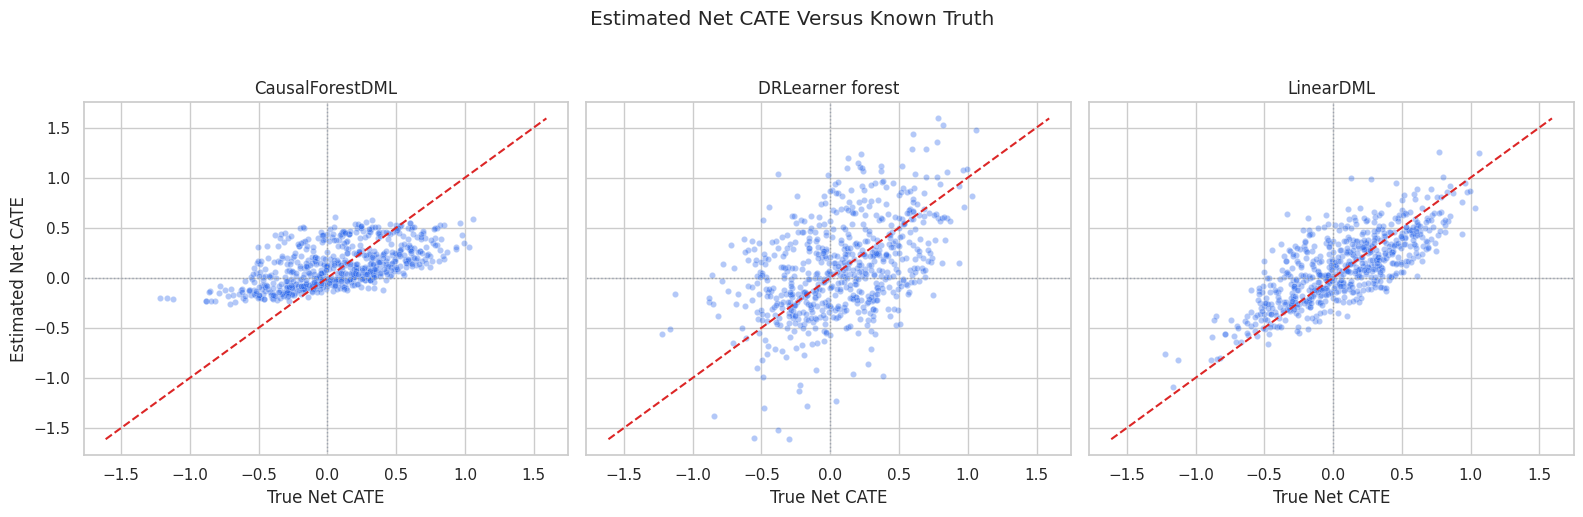

In [16]:
cate_plot_df = pd.concat(
    [
        pd.DataFrame({"true_net_cate": true_net_cate_test, "estimated_net_cate": linear_net_cate_test, "model": "LinearDML"}),
        pd.DataFrame({"true_net_cate": true_net_cate_test, "estimated_net_cate": forest_net_cate_test, "model": "CausalForestDML"}),
        pd.DataFrame({"true_net_cate": true_net_cate_test, "estimated_net_cate": dr_net_cate_test, "model": "DRLearner forest"}),
    ],
    ignore_index=True,
)
limits = [
    min(cate_plot_df["true_net_cate"].min(), cate_plot_df["estimated_net_cate"].min()),
    max(cate_plot_df["true_net_cate"].max(), cate_plot_df["estimated_net_cate"].max()),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)
for ax, (model_name, model_df) in zip(axes, cate_plot_df.groupby("model")):
    sample_df = model_df.sample(n=min(650, len(model_df)), random_state=RANDOM_SEED)
    sns.scatterplot(data=sample_df, x="true_net_cate", y="estimated_net_cate", alpha=0.35, s=20, color="#2563eb", ax=ax)
    ax.plot(limits, limits, color="#dc2626", linestyle="--", linewidth=1.5)
    ax.axhline(0, color="#9ca3af", linewidth=1, linestyle=":")
    ax.axvline(0, color="#9ca3af", linewidth=1, linestyle=":")
    ax.set_title(model_name)
    ax.set_xlabel("True Net CATE")
    ax.set_ylabel("Estimated Net CATE")

plt.suptitle("Estimated Net CATE Versus Known Truth", y=1.03)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "07_net_cate_recovery_scatter.png", dpi=160, bbox_inches="tight")
plt.show()

What this shows: the zero lines matter for policy. Points in the wrong quadrant represent units where the model would make the wrong treat-or-do-not-treat decision under a threshold rule.

## Build Score-Based Policies

This cell turns estimated net CATE scores into policy actions:

- threshold policy: treat if estimated net CATE is above zero;
- conservative policy: treat if the causal forest lower interval is above zero;
- top-k policies: treat the highest-scoring 20 percent under each model;
- oracle policies: use true net CATE, available only in simulation.

In [17]:
def top_k_policy(score, fraction):
    score = np.asarray(score)
    k = int(np.ceil(fraction * len(score)))
    action = np.zeros(len(score), dtype=int)
    if k > 0:
        action[np.argsort(score)[-k:]] = 1
    return action

BUDGET_FRACTION = 0.20

test_results = test_df.assign(
    linear_net_cate=linear_net_cate_test,
    forest_net_cate=forest_net_cate_test,
    dr_net_cate=dr_net_cate_test,
    forest_ci_lower=forest_lower_test,
    forest_ci_upper=forest_upper_test,
    forest_ci_width=forest_upper_test - forest_lower_test,
)

policy_actions = {
    "treat_none": np.zeros(len(test_results), dtype=int),
    "treat_all": np.ones(len(test_results), dtype=int),
    "linear_threshold_positive": (linear_net_cate_test > 0).astype(int),
    "forest_threshold_positive": (forest_net_cate_test > 0).astype(int),
    "forest_conservative_lower_positive": (forest_lower_test > 0).astype(int),
    "dr_threshold_positive": (dr_net_cate_test > 0).astype(int),
    "linear_top_20pct": top_k_policy(linear_net_cate_test, BUDGET_FRACTION),
    "forest_top_20pct": top_k_policy(forest_net_cate_test, BUDGET_FRACTION),
    "dr_top_20pct": top_k_policy(dr_net_cate_test, BUDGET_FRACTION),
    "oracle_threshold_positive": (true_net_cate_test > 0).astype(int),
    "oracle_top_20pct": top_k_policy(true_net_cate_test, BUDGET_FRACTION),
}

policy_action_summary = pd.DataFrame(
    [
        {"policy": name, "treatment_rate": action.mean(), "treated_rows": int(action.sum())}
        for name, action in policy_actions.items()
    ]
)
policy_action_summary.to_csv(TABLE_DIR / "07_score_policy_action_summary.csv", index=False)
display(policy_action_summary)

,policy,treatment_rate,treated_rows
0,treat_none,0.0000,0
1,treat_all,1.0000,1050
2,linear_threshold_positive,0.6086,639
3,forest_threshold_positive,0.6533,686
4,forest_conservative_lower_positive,0.2305,242
5,dr_threshold_positive,0.5543,582
6,linear_top_20pct,0.2000,210
7,forest_top_20pct,0.2000,210
8,dr_top_20pct,0.2000,210
9,oracle_threshold_positive,0.5581,586


What this shows: threshold policies and top-k policies can have very different treatment rates. Budgeted policies are easier to compare because they treat the same share of the population.

## Policy Value Function

In this truth-known simulation, policy gain over treating nobody is:

`mean(policy_action * true_net_CATE)`

This is not available in real observational data. Real policy value requires a credible evaluation design, such as an experiment or off-policy evaluation.

In [18]:
def evaluate_policy(action, true_net_cate, baseline_mu0=None):
    action = np.asarray(action).astype(int)
    gain = np.mean(action * true_net_cate)
    if baseline_mu0 is None:
        total_value = np.nan
    else:
        total_value = np.mean(baseline_mu0 + action * true_net_cate)
    return {
        "treatment_rate": action.mean(),
        "treated_rows": int(action.sum()),
        "true_policy_gain_vs_treat_none": gain,
        "true_total_policy_value": total_value,
        "average_true_net_cate_among_treated_by_policy": np.mean(true_net_cate[action == 1]) if action.sum() > 0 else 0.0,
        "share_selected_with_negative_true_net_cate": np.mean(true_net_cate[action == 1] < 0) if action.sum() > 0 else 0.0,
    }

baseline_mu0_test = test_df["mu0"].to_numpy()
policy_value_rows = []
for policy_name, action in policy_actions.items():
    row = {"policy": policy_name}
    row.update(evaluate_policy(action, true_net_cate_test, baseline_mu0=baseline_mu0_test))
    policy_value_rows.append(row)

policy_value_table = pd.DataFrame(policy_value_rows)
oracle_unconstrained_gain = policy_value_table.loc[policy_value_table["policy"].eq("oracle_threshold_positive"), "true_policy_gain_vs_treat_none"].iloc[0]
oracle_budget_gain = policy_value_table.loc[policy_value_table["policy"].eq("oracle_top_20pct"), "true_policy_gain_vs_treat_none"].iloc[0]
policy_value_table["regret_vs_oracle_threshold"] = oracle_unconstrained_gain - policy_value_table["true_policy_gain_vs_treat_none"]
policy_value_table["regret_vs_oracle_top_20pct"] = oracle_budget_gain - policy_value_table["true_policy_gain_vs_treat_none"]

policy_value_table.to_csv(TABLE_DIR / "07_score_policy_value_table.csv", index=False)
display(policy_value_table.sort_values("true_policy_gain_vs_treat_none", ascending=False))

,policy,treatment_rate,treated_rows,true_policy_gain_vs_treat_none,true_total_policy_value,average_true_net_cate_among_treated_by_policy,share_selected_with_negative_true_net_cate,regret_vs_oracle_threshold,regret_vs_oracle_top_20pct
9,oracle_threshold_positive,0.5581,586,0.1960,2.4740,0.3512,0.0000,0.0000,-0.0738
2,linear_threshold_positive,0.6086,639,0.1578,2.4358,0.2593,0.2316,0.0382,-0.0355
3,forest_threshold_positive,0.6533,686,0.1436,2.4216,0.2198,0.2813,0.0524,-0.0214
10,oracle_top_20pct,0.2000,210,0.1223,2.4003,0.6113,0.0000,0.0738,0.0000
5,dr_threshold_positive,0.5543,582,0.1076,2.3857,0.1942,0.3076,0.0884,0.0146
6,linear_top_20pct,0.2000,210,0.0918,2.3698,0.4590,0.0952,0.1042,0.0305
4,forest_conservative_lower_positive,0.2305,242,0.0748,2.3528,0.3244,0.1901,0.1213,0.0475
1,treat_all,1.0000,1050,0.0665,2.3445,0.0665,0.4419,0.1295,0.0558
8,dr_top_20pct,0.2000,210,0.0654,2.3434,0.3269,0.1952,0.1306,0.0569
7,forest_top_20pct,0.2000,210,0.0550,2.3330,0.2750,0.2429,0.1410,0.0673


What this shows: policy value depends on both ranking and treatment rate. A conservative policy may have high precision among treated units but lower total gain because it treats fewer rows.

## Policy Value Plot

This plot ranks score-based policies by true policy gain. The oracle rows are benchmarks, not deployable real-world policies.

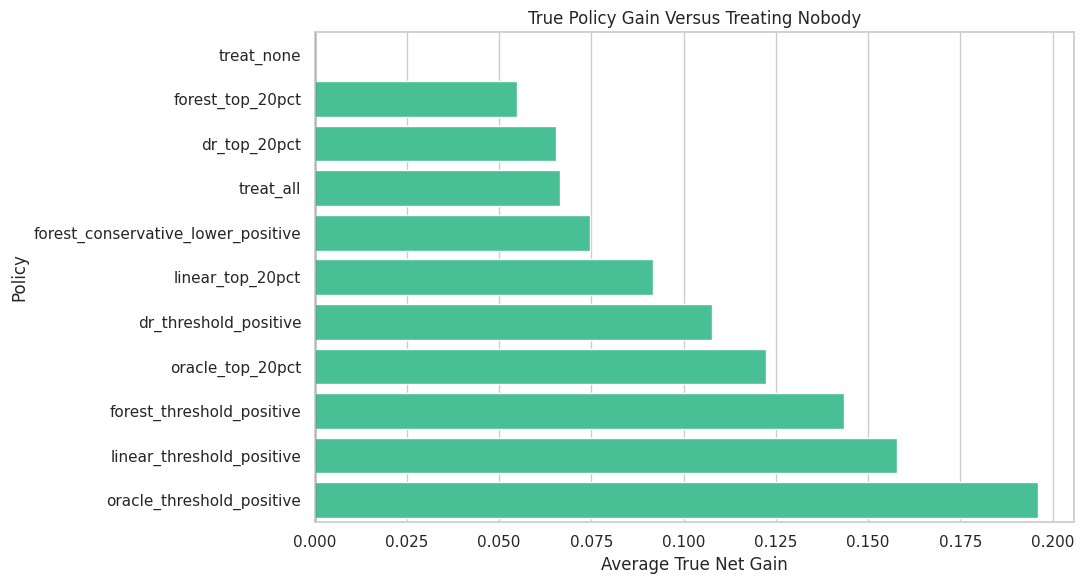

In [19]:
plot_policy_values = policy_value_table.sort_values("true_policy_gain_vs_treat_none", ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(
    data=plot_policy_values,
    x="true_policy_gain_vs_treat_none",
    y="policy",
    color="#34d399",
    ax=ax,
)
ax.axvline(0, color="#111827", linewidth=1)
ax.set_title("True Policy Gain Versus Treating Nobody")
ax.set_xlabel("Average True Net Gain")
ax.set_ylabel("Policy")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "07_score_policy_value.png", dpi=160, bbox_inches="tight")
plt.show()

What this shows: the best feasible score-based policy should get close to the oracle benchmark while treating a realistic share of the population and avoiding negative-benefit selections.

## Budget Curve

Instead of fixing one budget, we can examine policy gain across budget levels. This is useful when treatment capacity is uncertain.

In [20]:
budget_grid = np.arange(0.05, 0.55, 0.05)
budget_rows = []
for budget in budget_grid:
    for score_name, score in [
        ("LinearDML", linear_net_cate_test),
        ("CausalForestDML", forest_net_cate_test),
        ("DRLearner", dr_net_cate_test),
        ("Oracle", true_net_cate_test),
        ("Random expected", rng.permutation(true_net_cate_test)),
    ]:
        if score_name == "Random expected":
            action = top_k_policy(score, budget)
        else:
            action = top_k_policy(score, budget)
        budget_rows.append(
            {
                "budget_fraction": budget,
                "policy_score": score_name,
                "true_policy_gain": np.mean(action * true_net_cate_test),
                "average_true_net_cate_selected": np.mean(true_net_cate_test[action == 1]),
            }
        )

budget_curve = pd.DataFrame(budget_rows)
budget_curve.to_csv(TABLE_DIR / "07_budget_curve.csv", index=False)
display(budget_curve.head(12))

,budget_fraction,policy_score,true_policy_gain,average_true_net_cate_selected
0,0.0500,LinearDML,0.0330,0.6536
1,0.0500,CausalForestDML,0.0189,0.3736
2,0.0500,DRLearner,0.0211,0.4187
3,0.0500,Oracle,0.0412,0.8158
4,0.0500,Random expected,0.0065,0.1286
5,0.1000,LinearDML,0.0538,0.5381
6,0.1000,CausalForestDML,0.0325,0.3246
7,0.1000,DRLearner,0.0368,0.3680
8,0.1000,Oracle,0.0723,0.7232
9,0.1000,Random expected,0.0074,0.0739


What this shows: a single top-k number can hide how policies behave as budget changes. Budget curves show whether a ranking remains useful beyond the very top slice.

## Budget Curve Plot

The plot shows how true policy gain changes as the treatment budget increases.

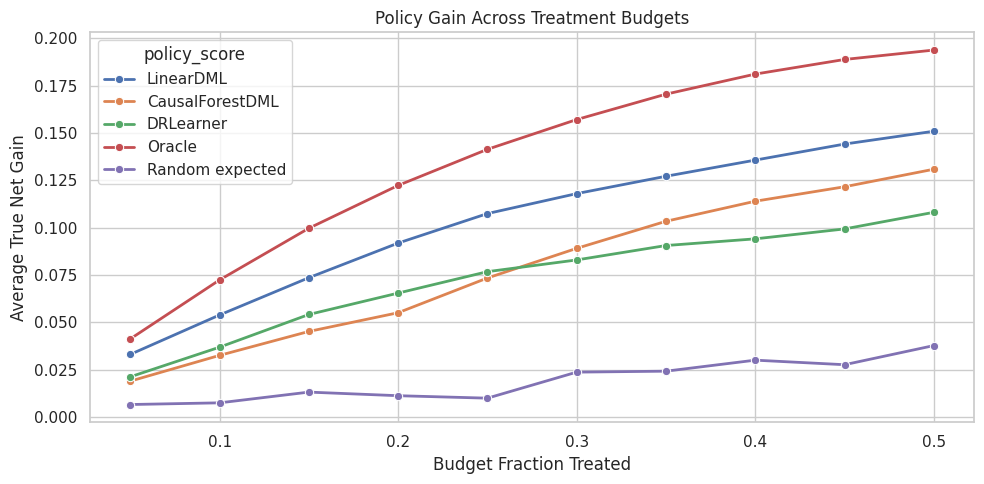

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(
    data=budget_curve,
    x="budget_fraction",
    y="true_policy_gain",
    hue="policy_score",
    marker="o",
    linewidth=2,
    ax=ax,
)
ax.set_title("Policy Gain Across Treatment Budgets")
ax.set_xlabel("Budget Fraction Treated")
ax.set_ylabel("Average True Net Gain")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.3f}")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "07_budget_curve.png", dpi=160, bbox_inches="tight")
plt.show()

What this shows: the oracle curve is the upper bound. A useful model stays clearly above random selection across the budget range where policy decisions are likely to be made.

## Fit Direct EconML Policy Learners

EconML also includes direct policy learners. Here we fit:

- `DRPolicyTree`: a shallow, interpretable policy tree;
- `DRPolicyForest`: an ensemble policy model.

Both are fit on observed net outcome, treatment, `X`, and `W`. The learned action is a direct recommendation rather than a post-hoc threshold on CATE estimates.

In [22]:
dr_policy_tree = DRPolicyTree(
    model_regression=RandomForestRegressor(n_estimators=130, min_samples_leaf=20, random_state=RANDOM_SEED + 5, n_jobs=-1),
    model_propensity=RandomForestClassifier(n_estimators=130, min_samples_leaf=20, random_state=RANDOM_SEED + 5, n_jobs=-1),
    min_propensity=0.035,
    cv=5,
    max_depth=3,
    min_samples_leaf=35,
    honest=True,
    random_state=RANDOM_SEED,
)
dr_policy_tree.fit(Y_net_train, T_train, X=X_train, W=W_train)
tree_policy_action = np.ravel(dr_policy_tree.predict(X_test)).astype(int)

dr_policy_forest = DRPolicyForest(
    model_regression=RandomForestRegressor(n_estimators=130, min_samples_leaf=20, random_state=RANDOM_SEED + 6, n_jobs=-1),
    model_propensity=RandomForestClassifier(n_estimators=130, min_samples_leaf=20, random_state=RANDOM_SEED + 6, n_jobs=-1),
    min_propensity=0.035,
    cv=5,
    n_estimators=80,
    max_depth=4,
    min_samples_leaf=35,
    max_samples=0.45,
    honest=True,
    n_jobs=-1,
    random_state=RANDOM_SEED,
)
dr_policy_forest.fit(Y_net_train, T_train, X=X_train, W=W_train)
forest_policy_action = np.ravel(dr_policy_forest.predict(X_test)).astype(int)

policy_learner_actions = {
    "DRPolicyTree": tree_policy_action,
    "DRPolicyForest": forest_policy_action,
}

policy_learner_summary = pd.DataFrame(
    [
        {"policy": name, **evaluate_policy(action, true_net_cate_test, baseline_mu0=baseline_mu0_test)}
        for name, action in policy_learner_actions.items()
    ]
)
policy_learner_summary.to_csv(TABLE_DIR / "07_direct_policy_learner_summary.csv", index=False)
display(policy_learner_summary)

,policy,treatment_rate,treated_rows,true_policy_gain_vs_treat_none,true_total_policy_value,average_true_net_cate_among_treated_by_policy,share_selected_with_negative_true_net_cate
0,DRPolicyTree,0.9295,976,0.0565,2.3345,0.0608,0.4457
1,DRPolicyForest,0.7733,812,0.1472,2.4252,0.1904,0.3103


What this shows: direct policy learners output actions, not CATE scores. They are attractive when the final object needs to be a decision rule, especially an interpretable tree.

## Combined Policy Comparison

Now we compare the strongest score-based rules with direct policy learners in one table.

In [23]:
selected_policy_names = [
    "treat_none",
    "treat_all",
    "forest_threshold_positive",
    "forest_conservative_lower_positive",
    "forest_top_20pct",
    "dr_top_20pct",
    "oracle_threshold_positive",
    "oracle_top_20pct",
]
combined_rows = []
for name in selected_policy_names:
    combined_rows.append({"policy": name, "policy_type": "score-based", **evaluate_policy(policy_actions[name], true_net_cate_test, baseline_mu0=baseline_mu0_test)})
for name, action in policy_learner_actions.items():
    combined_rows.append({"policy": name, "policy_type": "direct policy learner", **evaluate_policy(action, true_net_cate_test, baseline_mu0=baseline_mu0_test)})

combined_policy_comparison = pd.DataFrame(combined_rows)
combined_policy_comparison["regret_vs_oracle_threshold"] = oracle_unconstrained_gain - combined_policy_comparison["true_policy_gain_vs_treat_none"]
combined_policy_comparison["regret_vs_oracle_top_20pct"] = oracle_budget_gain - combined_policy_comparison["true_policy_gain_vs_treat_none"]
combined_policy_comparison.to_csv(TABLE_DIR / "07_combined_policy_comparison.csv", index=False)
display(combined_policy_comparison.sort_values("true_policy_gain_vs_treat_none", ascending=False))

,policy,policy_type,treatment_rate,treated_rows,true_policy_gain_vs_treat_none,true_total_policy_value,average_true_net_cate_among_treated_by_policy,share_selected_with_negative_true_net_cate,regret_vs_oracle_threshold,regret_vs_oracle_top_20pct
6,oracle_threshold_positive,score-based,0.5581,586,0.1960,2.4740,0.3512,0.0000,0.0000,-0.0738
9,DRPolicyForest,direct policy learner,0.7733,812,0.1472,2.4252,0.1904,0.3103,0.0488,-0.0249
2,forest_threshold_positive,score-based,0.6533,686,0.1436,2.4216,0.2198,0.2813,0.0524,-0.0214
7,oracle_top_20pct,score-based,0.2000,210,0.1223,2.4003,0.6113,0.0000,0.0738,0.0000
3,forest_conservative_lower_positive,score-based,0.2305,242,0.0748,2.3528,0.3244,0.1901,0.1213,0.0475
1,treat_all,score-based,1.0000,1050,0.0665,2.3445,0.0665,0.4419,0.1295,0.0558
5,dr_top_20pct,score-based,0.2000,210,0.0654,2.3434,0.3269,0.1952,0.1306,0.0569
8,DRPolicyTree,direct policy learner,0.9295,976,0.0565,2.3345,0.0608,0.4457,0.1395,0.0658
4,forest_top_20pct,score-based,0.2000,210,0.0550,2.3330,0.2750,0.2429,0.1410,0.0673
0,treat_none,score-based,0.0000,0,0.0000,2.2780,0.0000,0.0000,0.1960,0.1223


What this shows: direct policy learners and CATE-threshold policies answer the same decision problem in different ways. Their treatment rates may differ, so both value and action rate should be reported.

## Combined Policy Plot

The plot compares score-based policies and direct policy learners by true net gain.

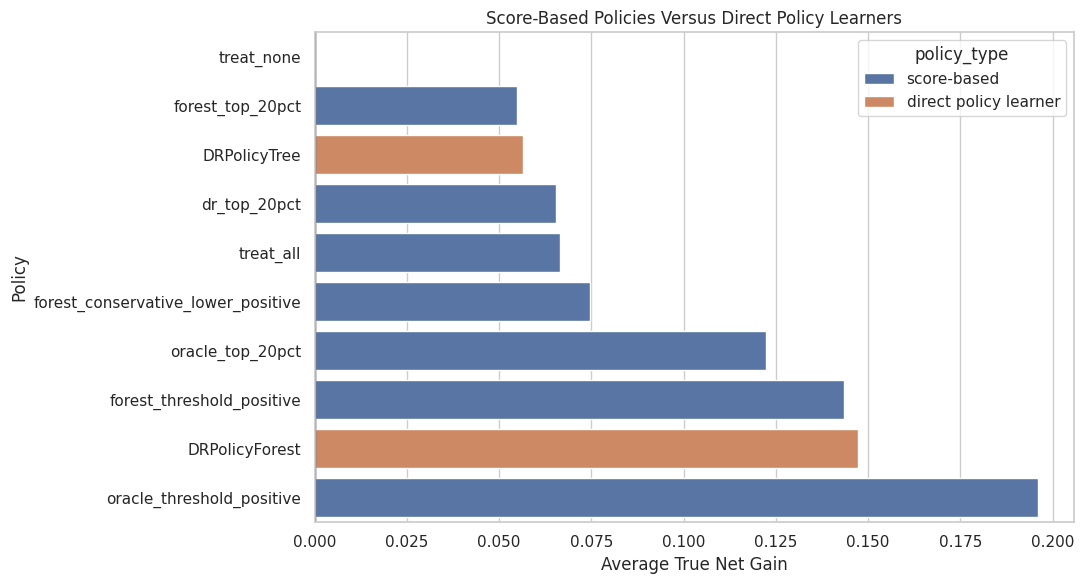

In [24]:
plot_combined = combined_policy_comparison.sort_values("true_policy_gain_vs_treat_none", ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(
    data=plot_combined,
    x="true_policy_gain_vs_treat_none",
    y="policy",
    hue="policy_type",
    dodge=False,
    ax=ax,
)
ax.axvline(0, color="#111827", linewidth=1)
ax.set_title("Score-Based Policies Versus Direct Policy Learners")
ax.set_xlabel("Average True Net Gain")
ax.set_ylabel("Policy")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "07_combined_policy_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

What this shows: policy choice is not only about which method is most sophisticated. A simpler rule can be competitive if the CATE score ranks units well.

## Policy Feature Importance

Direct policy learners can expose feature importance. This table shows which features the policy tree and policy forest used most when forming decisions.

In [25]:
policy_importance = pd.concat(
    [
        pd.DataFrame({"feature": effect_modifier_cols, "importance": np.ravel(dr_policy_tree.feature_importances()), "policy_model": "DRPolicyTree"}),
        pd.DataFrame({"feature": effect_modifier_cols, "importance": np.ravel(dr_policy_forest.feature_importances()), "policy_model": "DRPolicyForest"}),
    ],
    ignore_index=True,
)
policy_importance["abs_importance"] = policy_importance["importance"].abs()
policy_importance = policy_importance.sort_values(["policy_model", "abs_importance"], ascending=[True, False])
policy_importance.to_csv(TABLE_DIR / "07_policy_feature_importance.csv", index=False)
display(policy_importance)

,feature,importance,policy_model,abs_importance
9,friction_score,0.2310,DRPolicyForest,0.2310
10,content_affinity,0.2055,DRPolicyForest,0.2055
8,prior_engagement,0.2021,DRPolicyForest,0.2021
11,price_sensitivity,0.1916,DRPolicyForest,0.1916
7,baseline_need,0.1295,DRPolicyForest,0.1295
12,region_risk,0.0390,DRPolicyForest,0.0390
13,high_need_segment,0.0014,DRPolicyForest,0.0014
1,prior_engagement,1.0000,DRPolicyTree,1.0000
0,baseline_need,0.0000,DRPolicyTree,0.0000
2,friction_score,0.0000,DRPolicyTree,0.0000


What this shows: feature importance describes the fitted policy model, not the truth by itself. It helps explain which variables drove action recommendations.

## Policy Feature Importance Plot

The plot compares the most important policy features across tree and forest policy learners.

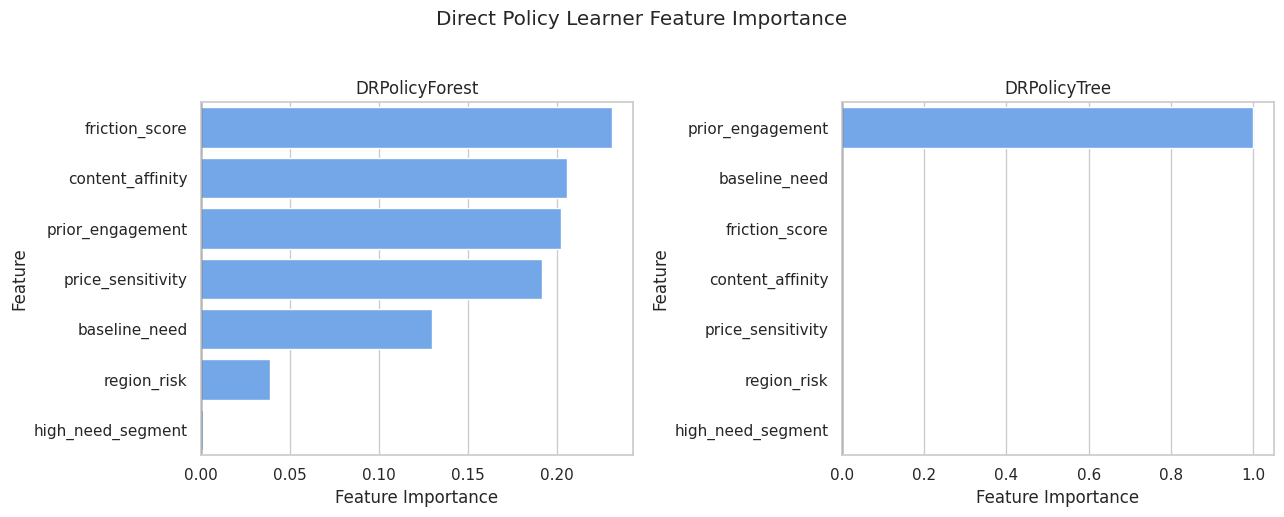

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=False)
for ax, (model_name, model_df) in zip(axes, policy_importance.groupby("policy_model")):
    sns.barplot(data=model_df, x="importance", y="feature", color="#60a5fa", ax=ax)
    ax.axvline(0, color="#111827", linewidth=1)
    ax.set_title(model_name)
    ax.set_xlabel("Feature Importance")
    ax.set_ylabel("Feature")

plt.suptitle("Direct Policy Learner Feature Importance", y=1.03)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "07_policy_feature_importance.png", dpi=160, bbox_inches="tight")
plt.show()

What this shows: the tree and forest may emphasize different features. A shallow tree is easier to explain; a forest can average over more decision patterns.

## Policy Tree Visualization

A shallow policy tree is valuable because it can be inspected directly. The next cell plots the learned tree structure.

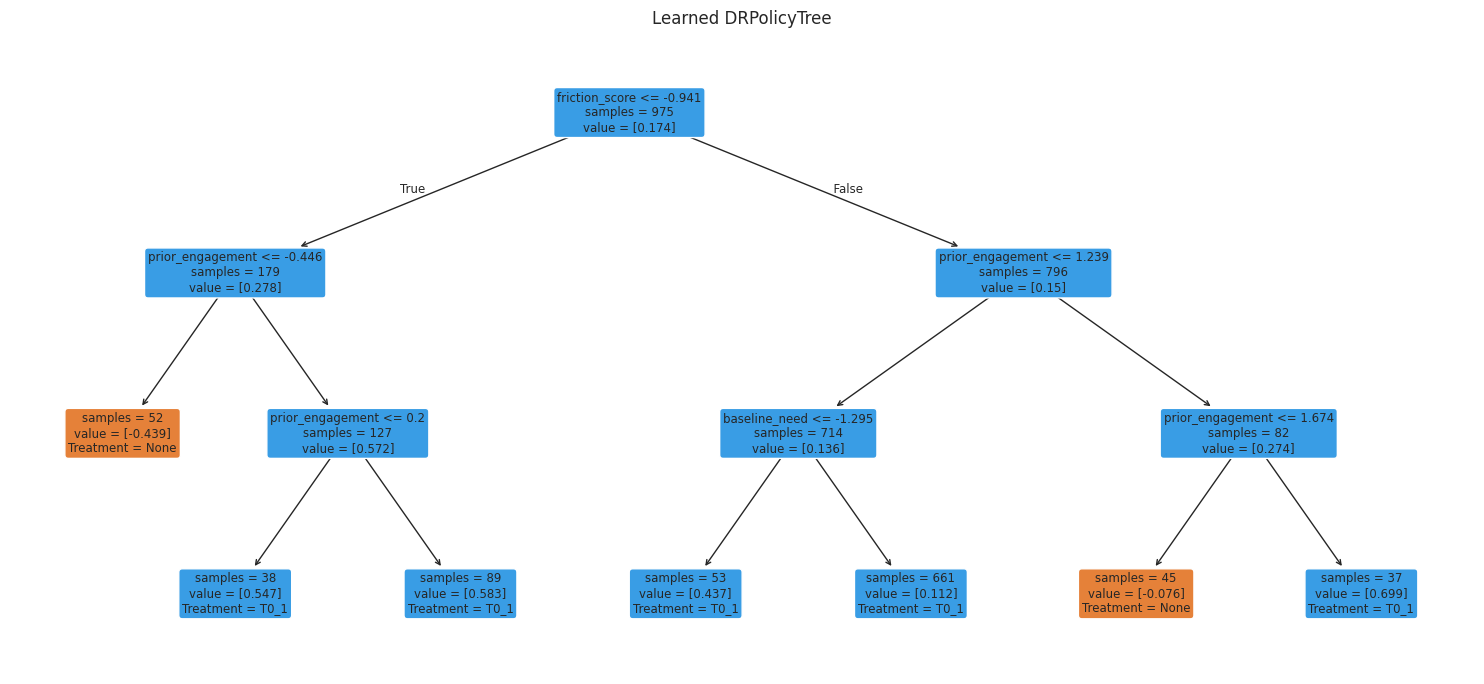

In [27]:
fig, ax = plt.subplots(figsize=(15, 7))
dr_policy_tree.policy_model_.plot(feature_names=effect_modifier_cols, treatment_names=dr_policy_tree.policy_treatment_names(), ax=ax)
ax.set_title("Learned DRPolicyTree")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "07_dr_policy_tree.png", dpi=160, bbox_inches="tight")
plt.show()

What this shows: the tree is an interpretable decision rule. It should still be evaluated by policy value and support; readability alone does not make a policy credible.

## Segment-Level Policy Behavior

A policy can have good overall value while concentrating treatment in particular segments. The next table summarizes treatment rates and true gain by segment for several policies.

In [28]:
segment_policy_frames = []
segment_policy_actions = {
    "observed_logging_policy": test_results["treatment"].to_numpy().astype(int),
    "forest_top_20pct": policy_actions["forest_top_20pct"],
    "forest_threshold_positive": policy_actions["forest_threshold_positive"],
    "DRPolicyTree": tree_policy_action,
    "DRPolicyForest": forest_policy_action,
    "oracle_top_20pct": policy_actions["oracle_top_20pct"],
}
for policy_name, action in segment_policy_actions.items():
    temp = test_results.assign(policy_action=action, policy=policy_name, selected_gain=action * true_net_cate_test)
    segment_summary = (
        temp.groupby(["policy", "high_need_segment", "region_risk"], observed=True)
        .agg(
            rows=("outcome", "size"),
            policy_treatment_rate=("policy_action", "mean"),
            true_policy_gain=("selected_gain", "mean"),
            true_net_cate_mean=("true_net_cate", "mean"),
            propensity_mean=("propensity", "mean"),
        )
        .reset_index()
    )
    segment_policy_frames.append(segment_summary)

segment_policy_summary = pd.concat(segment_policy_frames, ignore_index=True)
segment_policy_summary.to_csv(TABLE_DIR / "07_segment_policy_summary.csv", index=False)
display(segment_policy_summary)

,policy,high_need_segment,region_risk,rows,policy_treatment_rate,true_policy_gain,true_net_cate_mean,propensity_mean
0,observed_logging_policy,0,0,495,0.3293,0.0364,0.0291,0.3297
1,observed_logging_policy,0,1,247,0.3401,-0.0134,-0.1325,0.3796
2,observed_logging_policy,1,0,204,0.7157,0.2798,0.3546,0.7067
3,observed_logging_policy,1,1,104,0.8365,0.1167,0.1517,0.7616
4,forest_top_20pct,0,0,495,0.2323,0.0581,0.0291,0.3297
5,forest_top_20pct,0,1,247,0.2510,0.0217,-0.1325,0.3796
6,forest_top_20pct,1,0,204,0.1176,0.0897,0.3546,0.7067
7,forest_top_20pct,1,1,104,0.0865,0.0513,0.1517,0.7616
8,forest_threshold_positive,0,0,495,0.6222,0.1148,0.0291,0.3297
9,forest_threshold_positive,0,1,247,0.5911,0.0169,-0.1325,0.3796


What this shows: segment behavior is part of policy reporting. A policy that gains value by ignoring or over-targeting certain segments may need additional review.

## Segment Treatment Rate Plot

This plot compares how often each policy treats each segment.

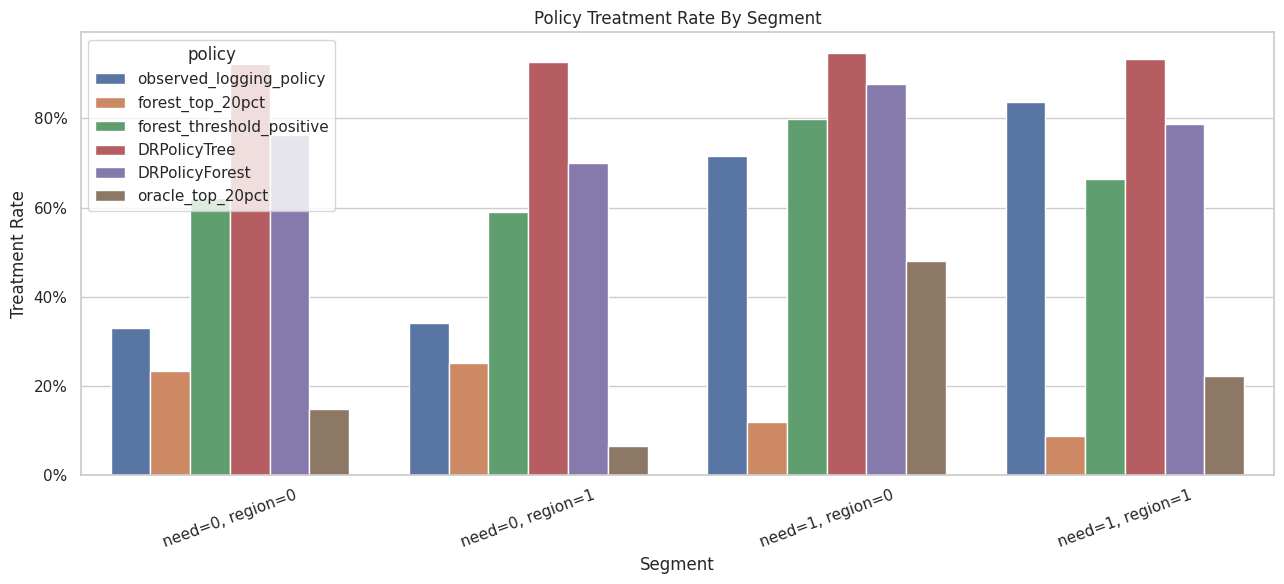

In [29]:
segment_plot_df = segment_policy_summary.copy()
segment_plot_df["segment"] = (
    "need=" + segment_plot_df["high_need_segment"].astype(str)
    + ", region=" + segment_plot_df["region_risk"].astype(str)
)

fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(
    data=segment_plot_df,
    x="segment",
    y="policy_treatment_rate",
    hue="policy",
    ax=ax,
)
ax.set_title("Policy Treatment Rate By Segment")
ax.set_xlabel("Segment")
ax.set_ylabel("Treatment Rate")
ax.tick_params(axis="x", rotation=20)
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "07_segment_policy_treatment_rate.png", dpi=160, bbox_inches="tight")
plt.show()

What this shows: policies encode priorities. Segment treatment-rate plots make those priorities explicit and easier to audit.

## Support-Aware Policy Diagnostics

A high-value policy can still be risky if it selects many rows from weak-overlap regions. The next table summarizes propensity and interval width among selected rows.

In [30]:
support_policy_actions = {
    "forest_threshold_positive": policy_actions["forest_threshold_positive"],
    "forest_conservative_lower_positive": policy_actions["forest_conservative_lower_positive"],
    "forest_top_20pct": policy_actions["forest_top_20pct"],
    "DRPolicyTree": tree_policy_action,
    "DRPolicyForest": forest_policy_action,
    "oracle_top_20pct": policy_actions["oracle_top_20pct"],
}

support_rows = []
for policy_name, action in support_policy_actions.items():
    selected = test_results.loc[action == 1]
    support_rows.append(
        {
            "policy": policy_name,
            "treated_rows": len(selected),
            "treatment_rate": action.mean(),
            "average_propensity_selected": selected["propensity"].mean() if len(selected) else np.nan,
            "share_selected_propensity_below_0_10": (selected["propensity"] < 0.10).mean() if len(selected) else 0.0,
            "share_selected_propensity_above_0_90": (selected["propensity"] > 0.90).mean() if len(selected) else 0.0,
            "average_forest_interval_width_selected": selected["forest_ci_width"].mean() if len(selected) else np.nan,
            "share_selected_negative_true_net_cate": (selected["true_net_cate"] < 0).mean() if len(selected) else 0.0,
        }
    )

support_policy_summary = pd.DataFrame(support_rows)
support_policy_summary.to_csv(TABLE_DIR / "07_support_policy_summary.csv", index=False)
display(support_policy_summary)

,policy,treated_rows,treatment_rate,average_propensity_selected,share_selected_propensity_below_0_10,share_selected_propensity_above_0_90,average_forest_interval_width_selected,share_selected_negative_true_net_cate
0,forest_threshold_positive,686,0.6533,0.4723,0.0816,0.0423,0.5749,0.2813
1,forest_conservative_lower_positive,242,0.2305,0.4001,0.0992,0.0083,0.5256,0.1901
2,forest_top_20pct,210,0.2000,0.3580,0.1333,0.0238,0.5995,0.2429
3,DRPolicyTree,976,0.9295,0.4605,0.0523,0.0256,0.5396,0.4457
4,DRPolicyForest,812,0.7733,0.4824,0.0567,0.0369,0.5537,0.3103
5,oracle_top_20pct,210,0.2000,0.6500,0.0000,0.0762,0.5406,0.0000


What this shows: policy value should be reported alongside support diagnostics. A policy that relies on extreme-propensity rows may need experimental validation before deployment.

## Threshold Sensitivity

A zero threshold is natural for net benefit, but analysts may choose a higher threshold to be conservative. This cell evaluates causal-forest threshold policies across several thresholds.

In [31]:
threshold_grid = np.round(np.arange(-0.15, 0.36, 0.05), 2)
threshold_rows = []
for threshold in threshold_grid:
    action = (forest_net_cate_test > threshold).astype(int)
    row = {"threshold": threshold}
    row.update(evaluate_policy(action, true_net_cate_test, baseline_mu0=baseline_mu0_test))
    threshold_rows.append(row)

threshold_sensitivity = pd.DataFrame(threshold_rows)
threshold_sensitivity.to_csv(TABLE_DIR / "07_threshold_sensitivity.csv", index=False)
display(threshold_sensitivity)

,threshold,treatment_rate,treated_rows,true_policy_gain_vs_treat_none,true_total_policy_value,average_true_net_cate_among_treated_by_policy,share_selected_with_negative_true_net_cate
0,-0.1500,0.9162,962,0.1102,2.3882,0.1203,0.3909
1,-0.1000,0.8276,869,0.1339,2.4120,0.1618,0.3406
2,-0.0500,0.7371,774,0.1442,2.4222,0.1956,0.3010
3,0.0000,0.6533,686,0.1436,2.4216,0.2198,0.2813
4,0.0500,0.5590,587,0.1398,2.4178,0.2500,0.2572
5,0.1000,0.4724,496,0.1283,2.4063,0.2716,0.2440
6,0.1500,0.3848,404,0.1107,2.3887,0.2876,0.2327
7,0.2000,0.3086,324,0.0917,2.3697,0.2972,0.2222
8,0.2500,0.2486,261,0.0730,2.3510,0.2936,0.2299
9,0.3000,0.2057,216,0.0572,2.3352,0.2780,0.2454


What this shows: raising the threshold usually treats fewer rows with higher average benefit among selected units. The best threshold depends on policy goals, costs, and risk tolerance.

## Threshold Sensitivity Plot

The plot shows the tradeoff between treatment rate and true policy gain as the threshold changes.

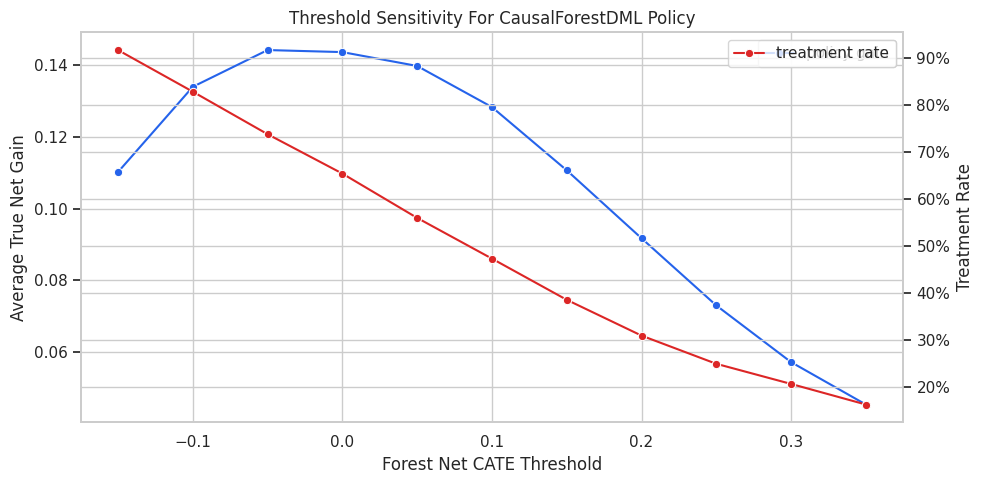

In [32]:
fig, ax1 = plt.subplots(figsize=(10, 5))
sns.lineplot(data=threshold_sensitivity, x="threshold", y="true_policy_gain_vs_treat_none", marker="o", color="#2563eb", ax=ax1, label="policy gain")
ax1.set_ylabel("Average True Net Gain")
ax1.set_xlabel("Forest Net CATE Threshold")
ax2 = ax1.twinx()
sns.lineplot(data=threshold_sensitivity, x="threshold", y="treatment_rate", marker="o", color="#dc2626", ax=ax2, label="treatment rate")
ax2.set_ylabel("Treatment Rate")
ax2.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax1.set_title("Threshold Sensitivity For CausalForestDML Policy")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "07_threshold_sensitivity.png", dpi=160, bbox_inches="tight")
plt.show()

What this shows: policy thresholds are business and risk decisions, not purely statistical choices. The curve makes the tradeoff visible.

## Policy Learning Guidance

This table summarizes when to use different policy approaches.

In [33]:
policy_guidance = pd.DataFrame(
    [
        {
            "situation": "No fixed budget and treatment cost is known",
            "reasonable policy": "Treat if estimated net CATE is above zero",
            "watchout": "Point estimates near zero are fragile; consider uncertainty or a margin.",
        },
        {
            "situation": "Fixed treatment capacity",
            "reasonable policy": "Top-k ranking by estimated net CATE",
            "watchout": "Budget curves should be checked instead of relying on one k value.",
        },
        {
            "situation": "Need an interpretable action rule",
            "reasonable policy": "DRPolicyTree or shallow tree over CATE scores",
            "watchout": "Interpretability can cost value; compare against score-based policies.",
        },
        {
            "situation": "Need stronger predictive action performance",
            "reasonable policy": "DRPolicyForest or flexible CATE ranking",
            "watchout": "The rule may be harder to explain and still needs support checks.",
        },
        {
            "situation": "Offline observational data only",
            "reasonable policy": "Treat learned policy as a candidate for evaluation",
            "watchout": "Real deployment should use experiments or valid off-policy evaluation.",
        },
    ]
)

policy_guidance.to_csv(TABLE_DIR / "07_policy_guidance.csv", index=False)
display(policy_guidance)

,situation,reasonable policy,watchout
0,No fixed budget and treatment cost is known,Treat if estimated net CATE is above zero,Point estimates near zero are fragile; conside...
1,Fixed treatment capacity,Top-k ranking by estimated net CATE,Budget curves should be checked instead of rel...
2,Need an interpretable action rule,DRPolicyTree or shallow tree over CATE scores,Interpretability can cost value; compare again...
3,Need stronger predictive action performance,DRPolicyForest or flexible CATE ranking,The rule may be harder to explain and still ne...
4,Offline observational data only,Treat learned policy as a candidate for evalua...,Real deployment should use experiments or vali...


What this shows: policy choice depends on operational constraints. The same CATE model can lead to different action rules under different costs, budgets, and risk tolerances.

## Policy Learning Checklist

Before presenting a treatment policy, it is worth checking the items below.

In [34]:
policy_checklist = pd.DataFrame(
    [
        {"check": "Treatment and outcome are clearly defined", "why_it_matters": "A policy acts on a specific intervention and optimizes a specific response."},
        {"check": "Treatment cost is included or explicitly justified", "why_it_matters": "Positive gross effects can become negative net effects after cost."},
        {"check": "All features are pre-treatment", "why_it_matters": "Policy rules must be available before deciding treatment."},
        {"check": "Overlap is inspected", "why_it_matters": "Unsupported regions make action recommendations extrapolative."},
        {"check": "CATE ranking quality is evaluated", "why_it_matters": "Targeting depends on ranking more than average effect alone."},
        {"check": "Policy value is compared with simple baselines", "why_it_matters": "A learned policy should beat treat-none, treat-all, random, and simple top-k rules."},
        {"check": "Treatment rate and budget are reported", "why_it_matters": "Policy value depends on how many units are treated."},
        {"check": "Segment-level action rates are audited", "why_it_matters": "Overall gain can hide uneven treatment allocation."},
        {"check": "Uncertainty or conservative margins are considered", "why_it_matters": "Policies based on noisy effects can over-treat borderline units."},
        {"check": "Deployment requires evaluation", "why_it_matters": "Offline policy value from observational data is not enough by itself."},
    ]
)

policy_checklist.to_csv(TABLE_DIR / "07_policy_learning_checklist.csv", index=False)
display(policy_checklist)

,check,why_it_matters
0,Treatment and outcome are clearly defined,A policy acts on a specific intervention and o...
1,Treatment cost is included or explicitly justi...,Positive gross effects can become negative net...
2,All features are pre-treatment,Policy rules must be available before deciding...
3,Overlap is inspected,Unsupported regions make action recommendation...
4,CATE ranking quality is evaluated,Targeting depends on ranking more than average...
5,Policy value is compared with simple baselines,"A learned policy should beat treat-none, treat..."
6,Treatment rate and budget are reported,Policy value depends on how many units are tre...
7,Segment-level action rates are audited,Overall gain can hide uneven treatment allocat...
8,Uncertainty or conservative margins are consid...,Policies based on noisy effects can over-treat...
9,Deployment requires evaluation,Offline policy value from observational data i...


What this shows: policy learning is a decision workflow, not just a model-fitting exercise. Good reporting includes value, support, uncertainty, and action-distribution diagnostics.

## Summary

This notebook turned CATE estimates into treatment policies.

The main takeaways are:

- policy learning is about choosing actions, not only estimating effects;
- treatment cost should be included when defining net benefit;
- threshold policies and budgeted top-k policies answer different operational problems;
- direct EconML policy learners can learn action rules without first exposing CATE scores;
- policy value should be compared against simple baselines and oracle benchmarks when available;
- segment treatment rates, support diagnostics, and uncertainty checks are essential for responsible policy reporting;
- real-world deployment requires prospective evaluation or valid off-policy evaluation.

The next tutorial can focus on interpreting CATE models more deeply with feature importance, SHAP-style explanations, and segment-level summaries.